In [32]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [33]:
df = pd.read_csv("C:/Users/강재원/Desktop/integrate_new.csv")

df.head()

,Country,Iso3,Year,current_usd,gdp_calculated,TIV_5Y_Share,TIV_5Y_Sum,human_hazard_score,share_gdp
0,Afghanistan,AFG,2000,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,2001,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,2002,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,2003,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,2004,125.111557,5145.96864,0.035532,34.4,NaN,0.024313


In [34]:
numeric_cols = [
    "Year",
    "current_usd",
    "share_gdp",
    "gdp_calculated",
    "TIV_5Y_Sum",
    "TIV_5Y_Share",
    "human_hazard_score"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# Year 없는 행 제거
df = df.dropna(
    subset=["Year", "Iso3", "Country"]
)

df["Year"] = df["Year"].astype(int)

In [35]:
print("데이터 크기:", df.shape)
print("중복:", df.duplicated(["Iso3", "Year"]).sum())

df.head()

데이터 크기: (4632, 9)
중복: 0


,Country,Iso3,Year,current_usd,gdp_calculated,TIV_5Y_Share,TIV_5Y_Sum,human_hazard_score,share_gdp
0,Afghanistan,AFG,2000,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,2001,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,2002,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,2003,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,2004,125.111557,5145.96864,0.035532,34.4,NaN,0.024313


In [9]:
metric_config = {

    "분쟁 위험도": {
        "column": "human_hazard_score",
        "unit": "점"
    },

    "TIV 수입 점유율": {
        "column": "TIV_5Y_Share",
        "unit": "%"
    },

    "군사비": {
        "column": "current_usd",
        "unit": "백만 US$"
    },

    "GDP": {
        "column": "gdp_calculated",
        "unit": "백만 US$"
    }
}

In [10]:
selected_metric = "TIV 수입 점유율"
selected_year = 2025
selected_country = "India"

In [11]:
metric_column = metric_config[selected_metric]["column"]
metric_unit = metric_config[selected_metric]["unit"]

print("선택 지표:", selected_metric)
print("사용 컬럼:", metric_column)

선택 지표: TIV 수입 점유율
사용 컬럼: TIV_5Y_Share


## 세계지도 히트맵 ##

In [43]:
map_df = df[         # 선택연도만 가져오게 함
    (df["Year"] == selected_year) &
    (df[metric_column].notna())
].copy()


if selected_metric in ["GDP", "군사비"]:

    map_df["MapValue"] = np.log10(
        map_df[metric_column].clip(lower=1)
    )

    color_col = "MapValue"

else:

    color_col = metric_column

In [40]:
fig_map = px.choropleth(
    map_df,

    locations="Iso3",
    locationmode="ISO-3",

    color=color_col,

    hover_name="Country",

    custom_data=[
        metric_column
    ],

    color_continuous_scale="YlOrRd",

    projection="natural earth",

    title=f"{selected_year}년 국가별 {selected_metric}"
)

In [41]:
if selected_metric == "TIV 수입 점유율":

    fig_map.update_traces(
        hovertemplate=
        "<b>%{hovertext}</b><br>"
        "TIV 수입 점유율: %{customdata[0]:.2f}%"
        "<extra></extra>"
    )

elif selected_metric == "분쟁 위험도":

    fig_map.update_traces(
        hovertemplate=
        "<b>%{hovertext}</b><br>"
        "분쟁 위험도: %{customdata[0]:.2f}"
        "<extra></extra>"
    )

else:

    fig_map.update_traces(
        hovertemplate=
        "<b>%{hovertext}</b><br>"
        + selected_metric +
        ": %{customdata[0]:,.0f} "
        + metric_unit +
        "<extra></extra>"
    )

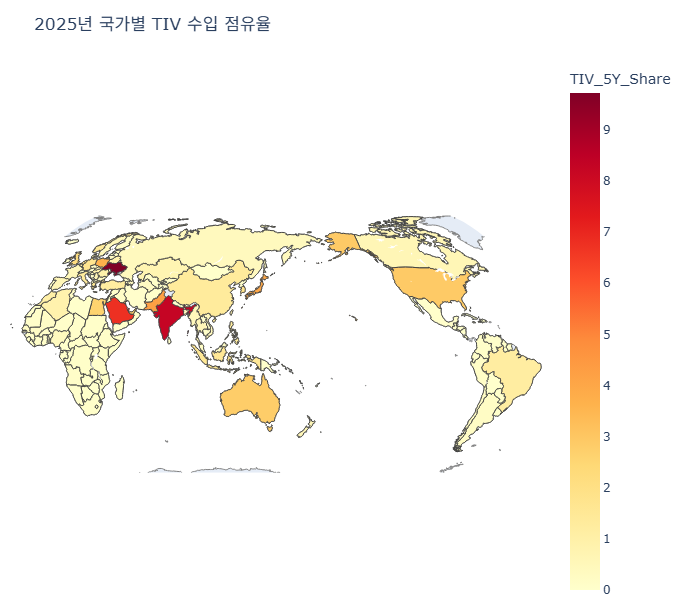

In [42]:
fig_map.update_layout(
    height=600,

    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="gray"
    ),

    margin=dict(
        l=0,
        r=0,
        t=60,
        b=0
    )
)

fig_map.show()

## 특정 국가 시계열 선그래프 ##

In [17]:
selected_country = "India"

In [18]:
country_df = df[
    (df["Country"] == selected_country) &
    (df[metric_column].notna())
].copy()

country_df = country_df.sort_values("Year")

country_df.head()

,Country,Iso3,Year,current_usd,gdp_calculated,TIV_5Y_Share,TIV_5Y_Sum,human_hazard_score,share_gdp
1904,India,IND,2004,20238.566527,7.154591e+05,9.279709,8984.04,NaN,0.028288
1905,India,IND,2005,23072.312925,7.927029e+05,9.417120,9198.30,NaN,0.029106
1906,India,IND,2006,23951.927958,8.936014e+05,9.282275,9635.13,NaN,0.026804
1907,India,IND,2007,28254.773450,1.140111e+06,8.906526,10032.49,NaN,0.024782
1908,India,IND,2008,33002.376727,1.254147e+06,7.549362,8877.86,NaN,0.026315


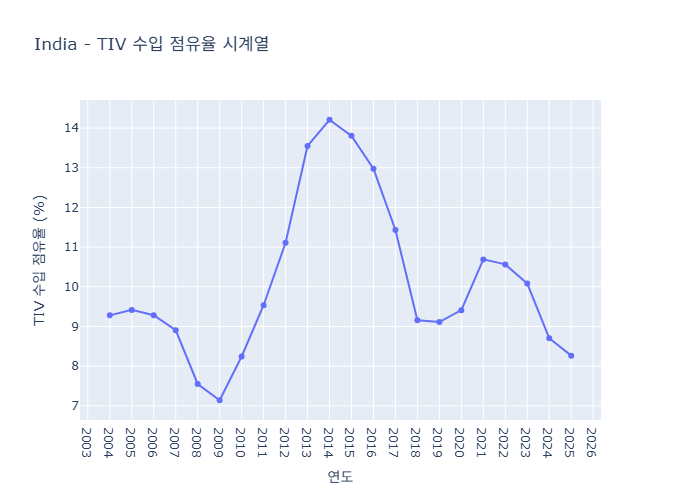

In [19]:
fig_line = px.line(
    country_df,

    x="Year",
    y=metric_column,

    markers=True,

    title=f"{selected_country} - {selected_metric} 시계열",

    labels={
        "Year": "연도",
        metric_column: f"{selected_metric} ({metric_unit})"
    }
)

fig_line.update_layout(
    height=500,

    hovermode="x unified",

    xaxis=dict(
        dtick=1
    )
)

fig_line.show()

## TOP10 국가 ##

In [20]:
top10 = (
    df[
        (df["Year"] == selected_year) &
        (df[metric_column].notna())
    ]

    [
        [
            "Country",
            "Iso3",
            metric_column
        ]
    ]

    .sort_values(
        metric_column,
        ascending=False
    )

    .head(10)
)

top10

,Country,Iso3,TIV_5Y_Share
4349,Ukraine,UKR,9.727706
1925,India,IND,8.263988
3581,Saudi Arabia,SAU,6.789426
3477,Qatar,QAT,6.445570
3221,Pakistan,PAK,4.231430
2159,Japan,JPN,3.970554
3351,Poland,POL,3.644099
4401,United States of America,USA,2.908293
2315,Kuwait,KWT,2.824822
203,Australia,AUS,2.809085


In [21]:
top10_plot = top10.sort_values(
    metric_column,
    ascending=True
)

In [22]:
fig_bar = px.bar(
    top10_plot,

    x=metric_column,
    y="Country",

    orientation="h",

    title=f"{selected_year}년 {selected_metric} Top10",

    labels={
        metric_column: f"{selected_metric} ({metric_unit})",
        "Country": "국가"
    },

    text=metric_column
)

In [23]:
if selected_metric == "TIV 수입 점유율":

    fig_bar.update_traces(
        texttemplate="%{x:.2f}%",
        textposition="outside"
    )
elif selected_metric == "분쟁 위험도":

    fig_bar.update_traces(
        texttemplate="%{x:.2f}",
        textposition="outside"
    )
else:

    fig_bar.update_traces(
        texttemplate="%{x:,.0f}",
        textposition="outside"
    )

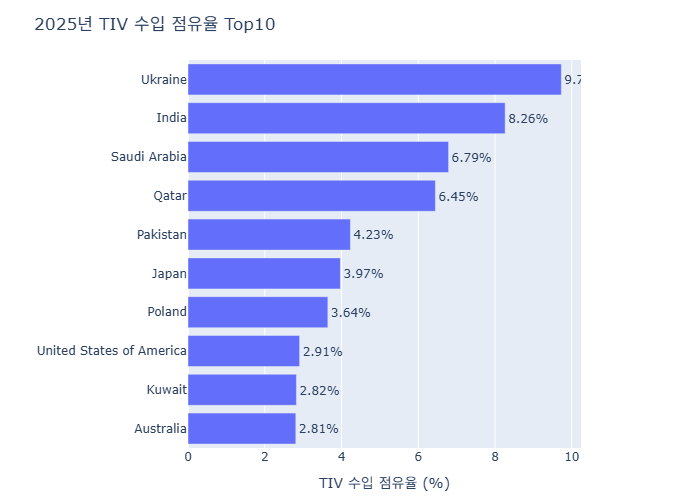

In [24]:
fig_bar.update_layout(
    height=500,

    showlegend=False,

    yaxis_title="",

    margin=dict(
        l=20,
        r=100,
        t=60,
        b=40
    )
)

fig_bar.show()

## 오각형 ##

In [60]:
# 분석할 국가 / 연도
selected_country = "Israel"
selected_year = 2025

In [61]:
# 5개 지표
indicator_map = {
    "분쟁 위험도": "human_hazard_score",
    "TIV 수입 점유율": "TIV_5Y_Share",
    "군사비": "current_usd",
    "GDP": "gdp_calculated",
    "군사비/GDP": "share_gdp"
}

In [62]:
# 해당 연도 데이터
year_df = df[
    df["Year"] == selected_year
].copy()

In [63]:
# 각 지표를 백분위 점수(0~100)로 변환 - 정규화
for label, col in indicator_map.items():

    year_df[col + "_scaled"] = (
        year_df[col]
        .rank(pct=True)
        * 100
    )

In [64]:
# Israel 데이터 가져오기


country_row = year_df[
    year_df["Country"] == selected_country
].iloc[0]


categories = list(indicator_map.keys())

In [65]:
# 백분위 점수
values = [
    country_row[indicator_map[label] + "_scaled"]
    for label in categories
]

In [66]:
# 실제 값
raw_values = [
    country_row[indicator_map[label]]
    for label in categories
]

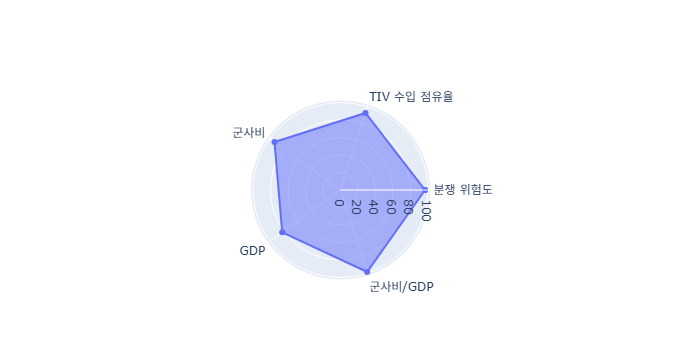

In [67]:
# 레이더 차트
fig = go.Figure()

fig.add_trace(
    go.Scatterpolar(

        r=values + [values[0]],

        theta=categories + [categories[0]],

        fill="toself",

        name=selected_country,

        customdata=np.array(
            raw_values + [raw_values[0]]
        ),

        hovertemplate=
            "<b>%{theta}</b><br>"
            "상대점수: %{r:.1f}<br>"
            "실제 값: %{customdata:,.2f}"
            "<extra></extra>"
    )
)

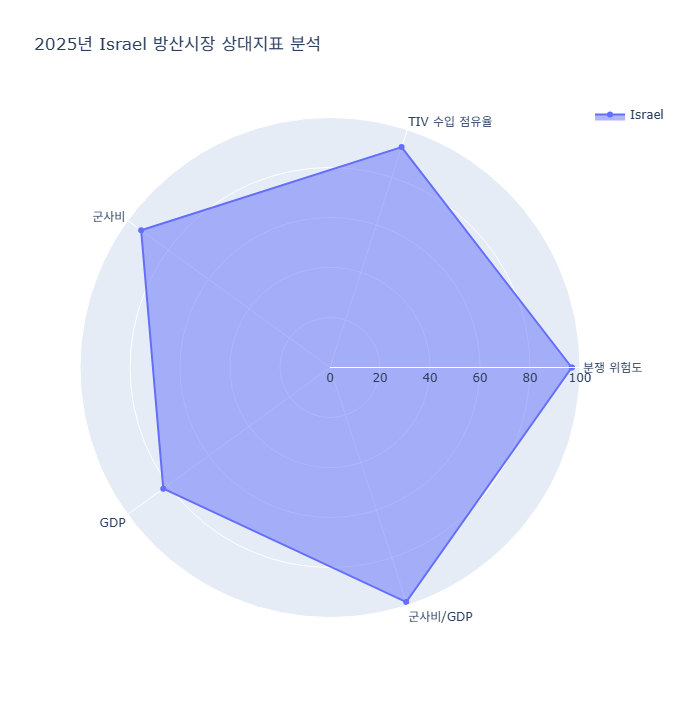

In [68]:
fig.update_layout(

    polar=dict(

        radialaxis=dict(
            visible=True,
            range=[0, 100],

            tickvals=[
                0,
                20,
                40,
                60,
                80,
                100
            ]
        )
    ),

    title=(
        f"{selected_year}년 "
        f"{selected_country} 방산시장 상대지표 분석"
    ),

    width=700,
    height=700,

    showlegend=True
)

fig.show()